In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
vocab_size = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shape:", X_train.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (25000, 200)


Step 3: Model Builder Function

In [4]:
def build_model(model_type):
    model = Sequential()

    if model_type == "RNN":
        model.add(SimpleRNN(64, input_shape=(max_len, 1)))

    elif model_type == "LSTM":
        model.add(LSTM(64, input_shape=(max_len, 1)))

    elif model_type == "GRU":
        model.add(GRU(64, input_shape=(max_len, 1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

Step 4: Reshape Data

In [5]:
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

Step 5: Train All Models

In [6]:
results = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type}...")

    model = build_model(model_type)

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=3,
        batch_size=64,
        validation_data=(X_test, y_test),
        verbose=1
    )

    end_time = time.time()

    loss, acc = model.evaluate(X_test, y_test)

    results[model_type] = {
        "accuracy": acc,
        "loss": loss,
        "time": end_time - start_time
    }


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.5021 - loss: 0.6954 - val_accuracy: 0.5008 - val_loss: 0.6971
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5018 - loss: 0.6945 - val_accuracy: 0.5022 - val_loss: 0.6940
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5069 - loss: 0.6940 - val_accuracy: 0.5023 - val_loss: 0.6943
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5023 - loss: 0.6943

Training LSTM...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.5303 - loss: 0.6955 - val_accuracy: 0.5451 - val_loss: 0.6871
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 88s 135ms/step - accuracy: 0.5473 - loss: 0.6859 - val_accuracy: 0.5246 - val_loss: 0.6923
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.5552 - loss: 0.6841 - val_accuracy: 0.5651 - val_loss: 0.6825
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5651 - loss: 0.6825

Training GRU...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 62s 15

📈 Step 6: Compare Results

In [7]:
for model in results:
    print(f"\n{model} Results:")
    print(f"Accuracy: {results[model]['accuracy']:.4f}")
    print(f"Loss: {results[model]['loss']:.4f}")
    print(f"Training Time: {results[model]['time']:.2f} sec")


RNN Results:
Accuracy: 0.5023
Loss: 0.6943
Training Time: 50.75 sec

LSTM Results:
Accuracy: 0.5651
Loss: 0.6825
Training Time: 182.77 sec

GRU Results:
Accuracy: 0.5486
Loss: 0.6862
Training Time: 183.21 sec


Step 7: Visualization

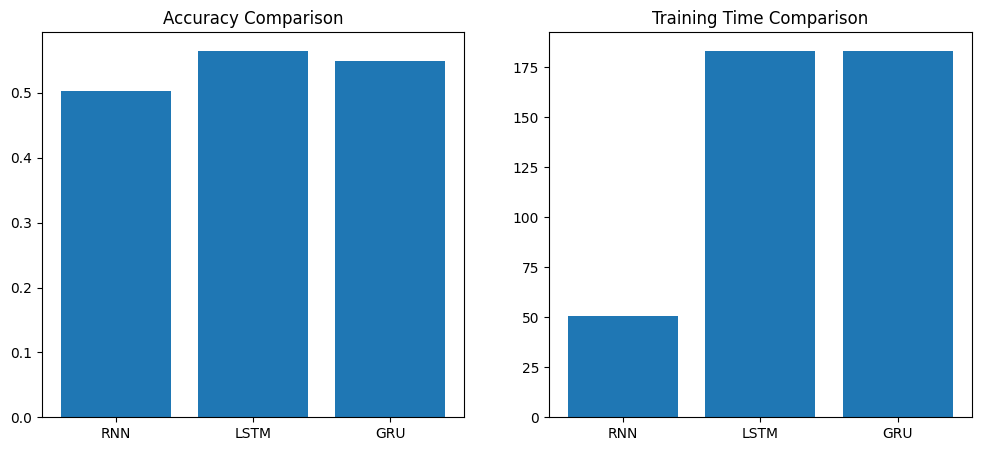

In [9]:
models = list(results.keys())
accuracy = [results[m]['accuracy'] for m in models]
time_taken = [results[m]['time'] for m in models]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")

plt.subplot(1,2,2)
plt.bar(models, time_taken)
plt.title("Training Time Comparison")

plt.show()